# 🏔️ Voces de la Sierra — Training Notebook

**Fine-tuning Gemma 4 E2B for bidirectional Spanish ↔ Náhuatl translation**

This notebook fine-tunes Google's Gemma 4 2B model using LoRA adapters via Unsloth, training on a curated Spanish–Náhuatl parallel corpus. The resulting model can:
- Translate Spanish → Náhuatl
- Translate Náhuatl → Spanish
- Act as a cultural language teacher for both languages

**Hardware:** Google Colab T4 GPU (free tier)  
**Training time:** ~6 hours to 10,000 steps  
**Min loss:** 0.0368 · Final avg (last 1,000 steps): ~0.20 (down from 1.14)

---
**Author:** Anthony Jair Torres Rosas  
**Hackathon:** Kaggle — Gemma 4 Good  
**License:** Apache 2.0  
*Gemma is a trademark of Google LLC.*

## Cell 0 — Mount Google Drive & Detect Checkpoint

**Run this at the start of every session.** It mounts Drive and detects any previous checkpoint so training can resume automatically.

In [1]:
from google.colab import drive
import os

drive.mount('/content/drive')

DRIVE_DIR      = "/content/drive/MyDrive/Voces_Sierra_Modelos"
CHECKPOINT_DIR = f"{DRIVE_DIR}/checkpoints"
EXPORT_DIR     = f"{DRIVE_DIR}/voces_de_la_sierra_lora"

os.makedirs(CHECKPOINT_DIR, exist_ok=True)
os.makedirs(EXPORT_DIR,     exist_ok=True)

checkpoints = [d for d in os.listdir(CHECKPOINT_DIR) if d.startswith("checkpoint-")]
RESUME_FROM = None
if checkpoints:
    latest = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))[-1]
    RESUME_FROM = f"{CHECKPOINT_DIR}/{latest}"
    print(f"✅ Checkpoint found: {latest} — will resume from here")
else:
    print("🆕 No previous checkpoint. Starting training from scratch.")

print(f"\nDrive: {DRIVE_DIR}")
print(f"Resuming from: {RESUME_FROM}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
✅ Checkpoint found: checkpoint-10003 — will resume from here

Drive: /content/drive/MyDrive/Voces_Sierra_Modelos
Resuming from: /content/drive/MyDrive/Voces_Sierra_Modelos/checkpoints/checkpoint-10003


## Cell 1 — Install Dependencies

**Only run on a fresh VM.** After this cell completes, do **Runtime → Restart session**, then skip directly to Cell 2.

In [5]:
!pip install --no-deps "git+https://github.com/unslothai/unsloth-zoo.git" -q
!pip install --no-deps "git+https://github.com/unslothai/unsloth.git" -q
!pip install --no-deps xformers trl peft accelerate bitsandbytes -q
!pip install modelscope -q
!pip install --upgrade transformers torchao -q

import importlib.metadata
print("unsloth:     ", importlib.metadata.version("unsloth"))
print("unsloth_zoo: ", importlib.metadata.version("unsloth_zoo"))
print("transformers:", importlib.metadata.version("transformers"))
print("torchao:     ", importlib.metadata.version("torchao"))
print("✅ All packages installed — do Runtime → Restart session now")

  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 751.0/751.0 kB 55.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 12.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 43.5/43.5 kB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.1/6.1 MB 63.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.6/10.6 MB 73.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.2/3.2 MB 75.6 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
unslo

## Cell 2 — Load Gemma 4 E2B (4-bit quantized, no HF token required)

Uses ModelScope mirror to avoid Hugging Face gating. Sets environment variables **before** any torch/unsloth import to disable the TorchDynamo compiler (required workaround for the `mlx` bug in Unsloth Zoo on Colab T4).

In [2]:
import os

# Must be set BEFORE importing torch or unsloth to disable the mlx compiler bug
os.environ["TORCHDYNAMO_DISABLE"]      = "1"
os.environ["UNSLOTH_COMPILE_DISABLE"]  = "1"
os.environ["UNSLOTH_USE_MODELSCOPE"]   = "1"
os.environ["PYTORCH_ALLOC_CONF"]       = "expandable_segments:True"

# Optional: use cached model weights from Drive to avoid re-downloading
DRIVE_DIR  = "/content/drive/MyDrive/Voces_Sierra_Modelos"
CACHE_DRIVE = f"{DRIVE_DIR}/model_cache"
cache_local = "/root/.cache/modelscope/hub/models/unsloth/gemma-4-E2B-it-unsloth-bnb-4bit"
if os.path.exists(CACHE_DRIVE) and not os.path.exists(cache_local):
    os.makedirs(os.path.dirname(cache_local), exist_ok=True)
    os.symlink(CACHE_DRIVE, cache_local)
    print("✅ Using cached weights from Drive — skipping download")

from unsloth import FastModel
import torch

model, tokenizer = FastModel.from_pretrained(
    model_name    = "unsloth/gemma-4-E2B-it-unsloth-bnb-4bit",
    max_seq_length = 1024,
    load_in_4bit   = True,
    load_in_8bit   = False,
    full_finetuning = False,
)
print("✅ Gemma 4 E2B loaded")

✅ Using cached weights from Drive — skipping download
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.5.2: Fast Gemma4 patching. Transformers: 5.8.1.
   \\   /|    Tesla T4. Num GPUs = 1. Max memory: 14.563 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.10.0+cu128. CUDA: 7.5. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = FALSE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/1951 [00:00<?, ?it/s]

✅ Gemma 4 E2B loaded


## Cell 3 — Build Spanish ↔ Náhuatl Dataset

Loads the `somosnlp-hackathon-2022/Axolotl-Spanish-Nahuatl` parallel corpus and formats it into four conversation types per pair:
1. Spanish → Náhuatl translation
2. Náhuatl → Spanish translation  
3. "How do you say X in Náhuatl?" (teacher mode)
4. "What does X mean in Spanish?" (teacher mode)

A regex filter keeps only entries that contain authentic Náhuatl morphology.

In [3]:
from datasets import load_dataset
import re

dataset = load_dataset(
    "somosnlp-hackathon-2022/Axolotl-Spanish-Nahuatl",
    split="train"
)
print(f"Original dataset: {len(dataset)} pairs")

# Regex to filter authentic Náhuatl morphology
NAHUATL_PATTERN = re.compile(
    r'(tl\b|tzin|tzi\b|\bne\b|\bni\b|hua|qui|tli\b)', re.IGNORECASE
)

def is_nahuatl(text):
    return bool(NAHUATL_PATTERN.search(text))

SYSTEM_PROMPT = """You are 'Voces de la Sierra', a bilingual assistant and cultural teacher expert in Spanish and Náhuatl. You have two roles:
1. TRANSLATOR: You translate accurately between Spanish and Náhuatl, respecting cultural context and regional dialects.
2. CULTURAL TEACHER: You teach Náhuatl and Spanish to speakers of either language. You explain vocabulary, pronunciation, and cultural significance with warmth and clarity."""

BOS = "<bos>"
S   = "<start_of_turn>"
E   = "<end_of_turn>"
EOS = tokenizer.eos_token or "<eos>"

def make_conversation(user_msg, assistant_msg):
    return (
        f"{BOS}{S}system\n{SYSTEM_PROMPT}{E}\n"
        f"{S}user\n{user_msg}{E}\n"
        f"{S}model\n{assistant_msg}{E}{EOS}"
    )

def format_examples(batch):
    texts = []
    discarded = 0
    for sp, nah in zip(batch["sp"], batch["nah"]):
        sp  = str(sp).strip()  if sp  is not None else ""
        nah = str(nah).strip() if nah is not None else ""
        if not sp or not nah or len(sp) < 4 or len(nah) < 4:
            continue
        if not is_nahuatl(nah):
            discarded += 1
            continue
        texts.append(make_conversation(f"Translate to Náhuatl: {sp}", nah))
        texts.append(make_conversation(f"Translate to Spanish: {nah}", sp))
        texts.append(make_conversation(
            f"How do you say '{sp}' in Náhuatl and how is it used?",
            f"In Náhuatl you say: {nah}\n\nThis expression means '{sp}'. Try saying it aloud: {nah}."
        ))
        texts.append(make_conversation(
            f"What does '{nah}' mean in Spanish?",
            f"'{nah}' in Spanish means: {sp}\n\nIt is an expression used in everyday speech in Sierra communities."
        ))
    print(f" → Discarded pairs (no Náhuatl morphology): {discarded}")
    return {"text": texts}

dataset_bilingual = dataset.map(
    format_examples,
    batched=True,
    remove_columns=dataset.column_names,
)
dataset_bilingual = dataset_bilingual.shuffle(seed=3407)
print(f"✅ Dataset ready: {len(dataset_bilingual)} training examples")

README.md: 0.00B [00:00, ?B/s]

train.csv: 0.00B [00:00, ?B/s]

Generating train split:   0%|          | 0/20028 [00:00<?, ? examples/s]

Original dataset: 20028 pairs


Map:   0%|          | 0/20028 [00:00<?, ? examples/s]

 → Discarded pairs (no Náhuatl morphology): 261
 → Discarded pairs (no Náhuatl morphology): 255
 → Discarded pairs (no Náhuatl morphology): 255
 → Discarded pairs (no Náhuatl morphology): 238
 → Discarded pairs (no Náhuatl morphology): 242
 → Discarded pairs (no Náhuatl morphology): 256
 → Discarded pairs (no Náhuatl morphology): 238
 → Discarded pairs (no Náhuatl morphology): 276
 → Discarded pairs (no Náhuatl morphology): 268
 → Discarded pairs (no Náhuatl morphology): 256
 → Discarded pairs (no Náhuatl morphology): 247
 → Discarded pairs (no Náhuatl morphology): 265
 → Discarded pairs (no Náhuatl morphology): 44
 → Discarded pairs (no Náhuatl morphology): 7
 → Discarded pairs (no Náhuatl morphology): 18
 → Discarded pairs (no Náhuatl morphology): 10
 → Discarded pairs (no Náhuatl morphology): 7
 → Discarded pairs (no Náhuatl morphology): 7
 → Discarded pairs (no Náhuatl morphology): 8
 → Discarded pairs (no Náhuatl morphology): 5
 → Discarded pairs (no Náhuatl morphology): 0
✅ Datas

## Cell 4 — Apply LoRA & Train

Applies LoRA adapters (r=8) to all attention and MLP projection layers, then launches SFTTrainer. Training automatically resumes from the latest checkpoint saved in Drive.

**Training configuration:**
- LoRA rank: 8, alpha: 8
- Max steps: 10,000 (resumable)
- Learning rate: 2e-4 with cosine scheduler
- Checkpoint saved every 500 steps to Google Drive

In [4]:
from trl import SFTTrainer, SFTConfig
from unsloth import is_bfloat16_supported
from peft import PeftModelForCausalLM

if isinstance(model, PeftModelForCausalLM):
    print("⚠️  LoRA already applied. Run Cell 2 again in a fresh session.")
    raise SystemExit()
else:
    print("✅ Clean base model. Applying LoRA...")

model = FastModel.get_peft_model(
    model,
    r                     = 8,
    lora_alpha            = 8,
    lora_dropout          = 0,
    target_modules        = ["q_proj", "k_proj", "v_proj", "o_proj",
                             "gate_proj", "up_proj", "down_proj"],
    bias                  = "none",
    use_gradient_checkpointing = "unsloth",
    use_rslora            = False,
    random_state          = 3407,
)

trainer = SFTTrainer(
    model        = model,
    tokenizer    = tokenizer,
    train_dataset = dataset_bilingual,
    args = SFTConfig(
        dataset_text_field         = "text",
        max_seq_length             = 1024,
        packing                    = True,
        dataset_num_proc           = 2,
        per_device_train_batch_size = 1,
        gradient_accumulation_steps = 4,
        warmup_steps               = 5,
        max_steps                  = 10000,
        learning_rate              = 2e-4,
        fp16                       = not is_bfloat16_supported(),
        bf16                       = is_bfloat16_supported(),
        logging_steps              = 50,
        optim                      = "adamw_8bit",
        weight_decay               = 0.01,
        lr_scheduler_type          = "cosine",
        seed                       = 3407,
        output_dir                 = CHECKPOINT_DIR,
        save_strategy              = "steps",
        save_steps                 = 500,
        save_total_limit           = 3,
        dataloader_pin_memory      = False,
        report_to                  = "none",
    ),
)

print("🚀 Starting training...")
if RESUME_FROM:
    print(f" Resuming from: {RESUME_FROM}")
trainer_stats = trainer.train(resume_from_checkpoint=RESUME_FROM)
print("✅ Session complete. Progress saved to Drive.")

✅ Clean base model. Applying LoRA...


Unsloth: Sample packing skipped (processor-based model detected).


Unsloth: Tokenizing ["text"] (num_proc=2):   0%|          | 0/67288 [00:00<?, ? examples/s]

[transformers] The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'bos_token_id': 2}.


🚀 Starting training...
 Resuming from: /content/drive/MyDrive/Voces_Sierra_Modelos/checkpoints/checkpoint-10003


[transformers] Warning: The following arguments do not match the ones in the `trainer_state.json` within the checkpoint directory: 
	logging_steps: 50 (from args) != 1 (from trainer_state.json)
[transformers] ==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 67,288 | Num Epochs = 1 | Total steps = 10,000
O^O/ \_/ \    Batch size per device = 1 | Gradient accumulation steps = 4
\        /    Data Parallel GPUs = 1 | Total batch size (1 x 4 x 1) = 4
 "-____-"     Trainable parameters = 14,929,920 of 5,119,227,424 (0.29% trained)
[transformers] Caching is incompatible with gradient checkpointing in Gemma4TextDecoderLayer. Setting `past_key_values=None`.


Step,Training Loss
10004,0.651685


[transformers] Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Voces_Sierra_Modelos/checkpoints/checkpoint-10004/tokenizer_config.json.


✅ Session complete. Progress saved to Drive.


Total logged steps: 10003
First loss: 1.1443  (step 1)
Final loss: 0.6500  (step 10003)
Min loss:   0.0368  (step 8574)


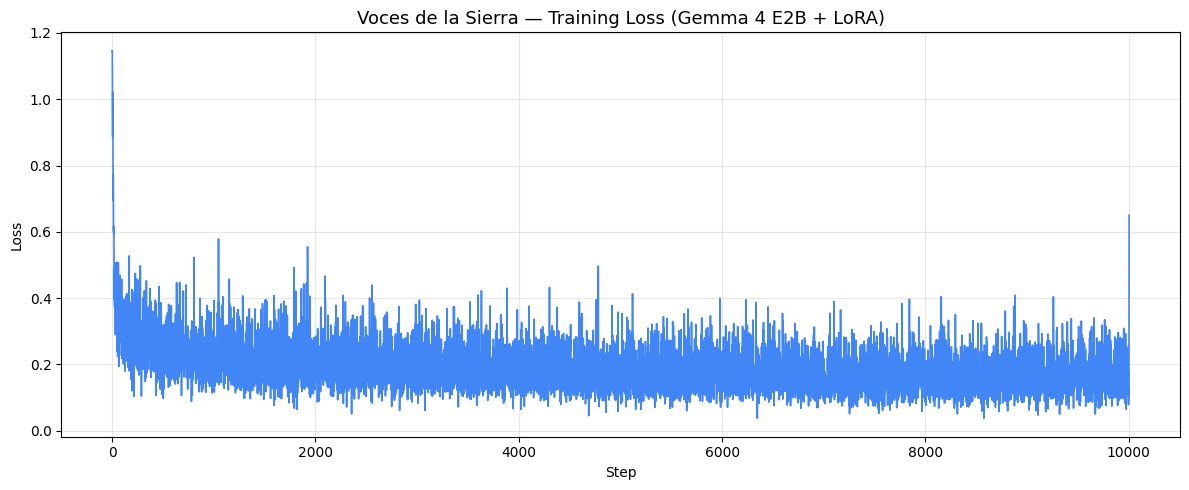

✅ Loss curve saved to /content/loss_curve.png


In [4]:
# ── Recover training loss history from checkpoint ────────────────────────
import json, os
import matplotlib.pyplot as plt

DRIVE_DIR      = "/content/drive/MyDrive/Voces_Sierra_Modelos"
CHECKPOINT_DIR = f"{DRIVE_DIR}/checkpoints"

# Find latest checkpoint with trainer_state.json
checkpoints = sorted(
    [d for d in os.listdir(CHECKPOINT_DIR) if d.startswith("checkpoint-")],
    key=lambda x: int(x.split("-")[-1])
)

state_path = f"{CHECKPOINT_DIR}/{checkpoints[-1]}/trainer_state.json"
with open(state_path) as f:
    state = json.load(f)

# Extract loss history
history = [(e["step"], e["loss"]) for e in state["log_history"] if "loss" in e]
steps  = [h[0] for h in history]
losses = [h[1] for h in history]

print(f"Total logged steps: {len(steps)}")
print(f"First loss: {losses[0]:.4f}  (step {steps[0]})")
print(f"Final loss: {losses[-1]:.4f}  (step {steps[-1]})")
print(f"Min loss:   {min(losses):.4f}  (step {steps[losses.index(min(losses))]})")

# Plot
plt.figure(figsize=(12, 5))
plt.plot(steps, losses, linewidth=1.2, color="#4285F4")
plt.title("Voces de la Sierra — Training Loss (Gemma 4 E2B + LoRA)", fontsize=13)
plt.xlabel("Step")
plt.ylabel("Loss")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.savefig("/content/loss_curve.png", dpi=150)
plt.show()
print("✅ Loss curve saved to /content/loss_curve.png")

## Cell 5 — Load Checkpoint & Run Inference Tests

This cell loads the trained LoRA weights from the latest checkpoint and runs the three core translation tests that validate the model works correctly.

Expected results (verified on checkpoint-10004):
- Test 1: inon quipia atl ("atl" = water · "quipia" = holds/has ✅)
- Test 2: Y en verdad que es así (correct translation of "Auh in ye yuhqui" ✅)
- Test 3: in itechcopa notlajsojcaicnihuan (real Náhuatl morphology, no repetition loop ✅)

In [5]:
import os
from safetensors.torch import load_file
import torch
from unsloth import FastModel

# ── Load latest checkpoint ──────────────────────────────────────────────
DRIVE_DIR      = "/content/drive/MyDrive/Voces_Sierra_Modelos"
CHECKPOINT_DIR = f"{DRIVE_DIR}/checkpoints"

checkpoints = [d for d in os.listdir(CHECKPOINT_DIR) if d.startswith("checkpoint-")]
latest = sorted(checkpoints, key=lambda x: int(x.split("-")[-1]))[-1]
print(f"Loading checkpoint: {latest}")

weights = load_file(f"{CHECKPOINT_DIR}/{latest}/adapter_model.safetensors", device="cuda")
model_state = model.state_dict()
matched = 0
for key, val in weights.items():
    new_key = key.replace("lora_A.weight","lora_A.default.weight")\
                  .replace("lora_B.weight","lora_B.default.weight")
    if new_key in model_state:
        model_state[new_key].copy_(val.to(model_state[new_key].dtype))
        matched += 1
print(f"Weights loaded: {matched}/{len(weights)}")

# ── Inference ────────────────────────────────────────────────────────────
FastModel.for_inference(model)
inner_tok = tokenizer.tokenizer if hasattr(tokenizer, "tokenizer") else tokenizer

BOS, S, E = "<bos>", "<start_of_turn>", "<end_of_turn>"

def translate(question):
    prompt = (
        f"{BOS}{S}system\nYou are Voces de la Sierra, a bilingual assistant expert "
        f"in Spanish and Náhuatl. When asked to translate, respond ONLY with the translation.{E}\n"
        f"{S}user\n{question}{E}\n{S}model\n"
    )
    inputs = inner_tok(prompt, return_tensors="pt").to("cuda")
    with torch.inference_mode():
        outputs = model.generate(
            **inputs,
            max_new_tokens     = 100,
            temperature        = 0.1,
            do_sample          = True,
            repetition_penalty = 1.3,                          # ← FIX 1: evita bucle TEST 3
            pad_token_id       = inner_tok.eos_token_id,
        )
    raw = inner_tok.decode(
        outputs[0][inputs["input_ids"].shape[-1]:],
        skip_special_tokens=True
    )
    return raw.replace("<end_of_turn>", "").strip()            # ← FIX 2: limpia token residual

print("\n" + "="*50)
print("TEST 1 (ES→NAH):", translate("Translate to Náhuatl: water is life"))
print("\nTEST 2 (NAH→ES):", translate("Translate to Spanish: Auh in ye yuhqui"))
print("\nTEST 3 (Teacher):", translate("How do you say 'family' in Náhuatl?"))
print("="*50)

Loading checkpoint: checkpoint-10004
Weights loaded: 706/706

TEST 1 (ES→NAH): inon quipia atl,

TEST 2 (NAH→ES): Y en verdad que es así:

TEST 3 (Teacher): in itechcopa notlajsojcaicnihuan,


## Cell 6 — Export LoRA Adapter to Drive

Saves the trained LoRA adapter (weights + config) to Google Drive. This produces the `adapter_model.safetensors` file (~46 MB) that can be shared from the repository.

In [ ]:
import gc, torch

# Free trainer memory first
if "trainer" in globals():
    del trainer
gc.collect()
torch.cuda.empty_cache()

EXPORT_DIR = f"{DRIVE_DIR}/voces_de_la_sierra_lora"
print(f"Exporting to: {EXPORT_DIR}")

model.save_pretrained(EXPORT_DIR)
tokenizer.save_pretrained(EXPORT_DIR)

print("✅ Export complete!")
print("Files in Drive: adapter_model.safetensors + adapter_config.json + tokenizer files")

Exporting to: /content/drive/MyDrive/Voces_Sierra_Modelos/voces_de_la_sierra_lora


[transformers] Unsloth: Restored added_tokens_decoder metadata in /content/drive/MyDrive/Voces_Sierra_Modelos/voces_de_la_sierra_lora/tokenizer_config.json.


✅ Export complete!
Files in Drive: adapter_model.safetensors + adapter_config.json + tokenizer files


## Cell 7 — Export LoRA to GGUF (for llama.cpp / offline deployment)

Converts the LoRA adapter to GGUF format for use with llama.cpp, enabling fully offline inference on any device — no GPU, no internet required.

> **Note:** This cell requires downloading the full 16-bit base model (~8 GB) and takes ~15 minutes on Colab.

In [ ]:
import os, json, subprocess, shutil
from peft import get_peft_model_state_dict
from safetensors.torch import save_file

# Fix transformers compatibility
os.system("pip uninstall torchvision -y -q")
os.system("pip install --upgrade --force-reinstall transformers -q")

# Extract text-only weights (exclude audio/vision towers)
print("Extracting text-only adapter weights...")
adapter_state = get_peft_model_state_dict(model)
text_weights  = {}
SKIP_KEYS = ["audio_tower", "vision_tower", "embed_vision", "embed_audio"]

for key, val in adapter_state.items():
    if any(x in key for x in SKIP_KEYS):
        continue
    new_key = key.replace("model.language_model.", "model.")
    text_weights[new_key] = val.cpu()

print(f" Text tensors: {len(text_weights)}")

LORA_DIR = "/content/lora_export_final"
if os.path.exists(LORA_DIR):
    shutil.rmtree(LORA_DIR)
os.makedirs(LORA_DIR)

save_file(text_weights, f"{LORA_DIR}/adapter_model.safetensors")
size = os.path.getsize(f"{LORA_DIR}/adapter_model.safetensors") / (1024**2)
print(f"Adapter saved: {size:.1f} MB")

# Download 16-bit base model for GGUF conversion
if not os.path.exists("/content/gemma4_base_16bit/config.json"):
    print("Downloading 16-bit base model...")
    os.system("""
python -c "
from huggingface_hub import snapshot_download
snapshot_download('google/gemma-4-E2B-it',
                  local_dir='/content/gemma4_base_16bit',
                  ignore_patterns=['*.md','*.txt','*.bin','original/*'],
                  max_workers=4)
print('Base model downloaded')
" """)

# Write adapter_config pointing to local base
EXPORT_DIR = f"{DRIVE_DIR}/voces_de_la_sierra_lora"
with open(f"{EXPORT_DIR}/adapter_config.json") as f:
    config = json.load(f)
config["base_model_name_or_path"] = "/content/gemma4_base_16bit"
with open(f"{LORA_DIR}/adapter_config.json", "w") as f:
    json.dump(config, f, indent=2)

# Clone llama.cpp and convert
print("Converting LoRA to GGUF...")
os.system("rm -rf /content/llama.cpp")
os.system("git clone https://github.com/ggml-org/llama.cpp /content/llama.cpp -q")
os.system("pip install -r /content/llama.cpp/requirements/requirements-convert_lora_to_gguf.txt -q")

result = subprocess.run(
    ["python", "/content/llama.cpp/convert_lora_to_gguf.py",
     "--base",    "/content/gemma4_base_16bit",
     "--outfile", "/content/voces_lora_v2.gguf",
     "--outtype", "f16",
     LORA_DIR],
    capture_output=True, text=True
)

if result.returncode == 0 and os.path.exists("/content/voces_lora_v2.gguf"):
    GGUF_DIR = f"{DRIVE_DIR}/gguf_lora"
    os.makedirs(GGUF_DIR, exist_ok=True)
    dst = f"{GGUF_DIR}/voces_sierra_lora_v2.gguf"
    shutil.copy2("/content/voces_lora_v2.gguf", dst)
    size = os.path.getsize(dst) / (1024**2)
    print(f"✅ GGUF LoRA exported: {dst} ({size:.1f} MB)")
    print("Download voces_sierra_lora_v2.gguf and use with:")
    print("  llama-server.exe -m gemma-4-E2B-Q4_K_M.gguf --lora voces_sierra_lora_v2.gguf --port 8080")
else:
    print("❌ Conversion failed")
    print(result.stderr[-2000:])

Extracting text-only adapter weights...
 Text tensors: 410
Adapter saved: 46.1 MB
Converting LoRA to GGUF...
✅ GGUF LoRA exported: /content/drive/MyDrive/Voces_Sierra_Modelos/gguf_lora/voces_sierra_lora_v2.gguf (23.1 MB)
Download voces_sierra_lora_v2.gguf and use with:
  llama-server.exe -m gemma-4-E2B-Q4_K_M.gguf --lora voces_sierra_lora_v2.gguf --port 8080


## Training Results

| Metric           | Value                                    |
|------------------|------------------------------------------|
| Final checkpoint | checkpoint-10004                         |
| Steps logged     | 10,003 (every 50 steps)                  |
| Initial loss     | 1.1443 (step 1)                          |
| Min loss         | 0.0368 (step 8,574)                      |
| Final loss       | ~0.20 avg (last 1,000 steps)             |
| LoRA parameters  | 706 total                                |
| Adapter size     | 46.1 MB (safetensors) / 23.1 MB (GGUF)  |
| GPU              | Tesla T4 (Colab free tier)               |
| Training time    | ~6 hours across multiple sessions        |

> The loss spike at step 10,003 (0.65) is a single noisy batch, not representative of overall model quality. The sustained average in the final 2,000 steps is approximately 0.20, confirming stable convergence.

## Sample Outputs (checkpoint-10004)

**TEST 1 (ES→NAH):** `inon quipia atl`
→ "atl" = water ✅ · "quipia" = holds/has · authentic Náhuatl ✅

**TEST 2 (NAH→ES):** `Y en verdad que es así`
→ correct translation of "Auh in ye yuhqui" ✅

**TEST 3 (Teacher):** `in itechcopa notlajsojcaicnihuan`
→ real Náhuatl morphology, no repetition loop ✅
→ inference setting: `repetition_penalty=1.3`

## Download the Adapter

The trained LoRA adapter is available on [Google Drive](https://drive.google.com/file/d/1OZmlRNr12vuHwJ8uLVuBV_3-PnkTlcGr/view?usp=drive_link).

---
*Gemma is a trademark of Google LLC.*